In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dateutil.parser import parse as parse_date

In [151]:
test_path = "84_months.test.csv"

df = pd.read_csv(test_path)

df['timestamp'] = pd.to_datetime(df['timestamp'])

Anomalies

In [152]:
# read in labels csv 
labels_df = pd.read_csv("labels.csv",  parse_dates=["StartTime", "EndTime"], date_parser=lambda x: parse_date(x, ignoretz=True))

# read in anomaly_types csv 
anomaly_types_df = pd.read_csv("anomaly_types.csv")


C:\Users\angus\AppData\Local\Temp\ipykernel_15688\2239488993.py:2: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  labels_df = pd.read_csv("labels.csv",  parse_dates=["StartTime", "EndTime"], date_parser=lambda x: parse_date(x, ignoretz=True))


In [153]:
start_time, end_time = df['timestamp'].min(), df['timestamp'].max()

labels_in_timeperiod = labels_df[(labels_df['StartTime'] <= end_time) & (labels_df['EndTime'] >= start_time)]

anomalies_ids_in_period = anomaly_types_df[anomaly_types_df['ID'].isin(labels_in_timeperiod['ID'])]

In [154]:
#print(labels_df.head())

In [155]:
# subset 41-46
subset_channels = ['channel_41', 'channel_42', 'channel_43', 'channel_44', 'channel_45', 'channel_46']
# subset 41-46
anomaly_subset = ['is_anomaly_' + channel for channel in subset_channels]


C:\Users\angus\AppData\Local\Temp\ipykernel_15688\2031230049.py:22: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rolling_series_plot = rolling_series.resample('1M').mean()


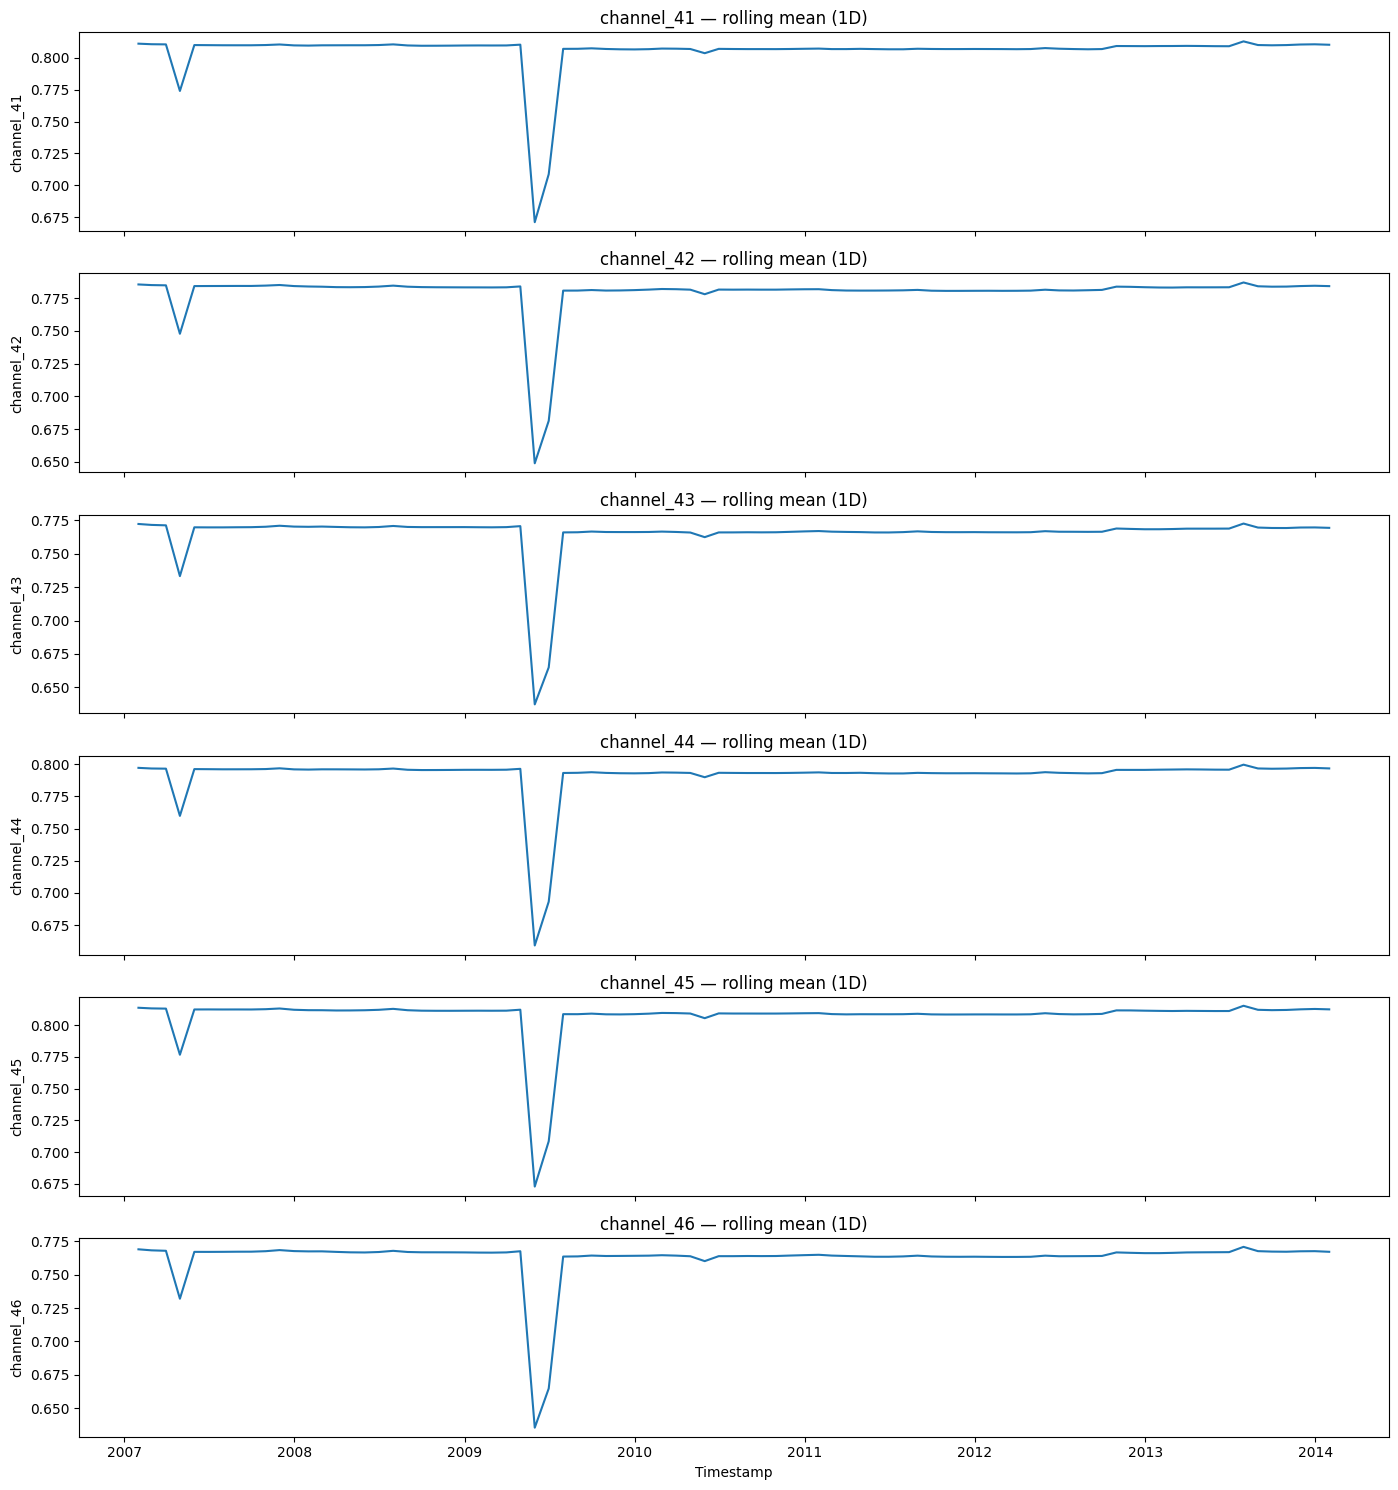

In [156]:
def plot_rolling_avg_channels(
    df,
    channels,
    window='1D'
):
    df = df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.set_index('timestamp')

    fig, axs = plt.subplots(len(channels), 1,
                            figsize=(14, 2.5 * len(channels)),
                            sharex=True)

    if len(channels) == 1:
        axs = [axs]

    for ax, ch in zip(axs, channels):

        rolling_series = df[ch].rolling(window).mean()

        # downsample before plotting (VERY IMPORTANT)
        rolling_series_plot = rolling_series.resample('1M').mean()

        ax.plot(rolling_series_plot.index, rolling_series_plot.values)
        ax.set_ylabel(ch)
        ax.set_title(f"{ch} — rolling mean ({window})")

    axs[-1].set_xlabel("Timestamp")

    plt.tight_layout()
    plt.show()


plot_rolling_avg_channels(df, subset_channels, window='1D')

In [157]:
for channel in subset_channels:
    channel_df = labels_df[labels_df['Channel'] == channel]
    unique_events = channel_df['ID'].unique()
    print(f"Channel: {channel}, Number of anomalies: {len(unique_events)}")

Channel: channel_41, Number of anomalies: 118
Channel: channel_42, Number of anomalies: 116
Channel: channel_43, Number of anomalies: 116
Channel: channel_44, Number of anomalies: 115
Channel: channel_45, Number of anomalies: 117
Channel: channel_46, Number of anomalies: 114


finding percentage of annotated points

In [158]:
# find number of anomalous points in this dataset for channels 41-46
# subset 41-46
subset_channels = ['channel_41', 'channel_42', 'channel_43', 'channel_44', 'channel_45', 'channel_46']
anomaly_subset = ['is_anomaly_' + channel for channel in subset_channels]

def find_num_annotated_points(df, anomaly_subset):
    # count number of anomalous points per channel
    total_anomalous_points = 0
    num_points = 0
    for channel in anomaly_subset:
        print(df[channel].unique())
        # find the number of points where the value in the channel is non zero
        num_anomalous_points = (df[channel] != 0).sum()
        #print(f"Channel: {channel}, Number of anomalous points: {num_anomalous_points}")
        total_anomalous_points += num_anomalous_points
        num_points += len(df[channel])

        print(num_anomalous_points/ len(df[channel]))


    print(f"Total number of anomalous points across channels 41-46: {total_anomalous_points}")
    print(f"Total number of points across channels 41-46: {num_points}")
    anomaly_percentage = (total_anomalous_points / num_points) * 100
    print(f"Percentage of anomalous points across channels 41-46: {anomaly_percentage:.6f}%")

print("Finding number of annotated points in test dataset for channels 41-46:")
find_num_annotated_points(df, anomaly_subset)




Finding number of annotated points in test dataset for channels 41-46:
[0 1 2]
0.018079724221129873
[0 1 2]
0.018087600203200337
[0 1 2]
0.018079724221129873
[0 1 2]
0.01807673677965487
[0 1 2]
0.01807931684274692
[0 1 2]
0.018074699887740096
Total number of anomalous points across channels 41-46: 798848
Total number of points across channels 41-46: 44184966
Percentage of anomalous points across channels 41-46: 1.807963%


In [159]:
pred_path_transformer = r"transformer\pred.csv"

df_pred_transformer = pd.read_csv(pred_path_transformer)

df_pred_energy_transformer = pd.read_csv(pred_path_transformer.replace(".csv", "_energy.csv"))

# converting to datetime
df_pred_transformer['timestamp'] = pd.to_datetime(df_pred_transformer['timestamp'])
df_pred_energy_transformer['timestamp'] = pd.to_datetime(df_pred_energy_transformer['timestamp'])

In [160]:
print(df_pred_energy_transformer.head(5))

            timestamp  channel_41  channel_42  channel_43  channel_44  \
0 2007-01-01 00:00:00         0.0         0.0         0.0         0.0   
1 2007-01-01 00:00:30         0.0         0.0         0.0         0.0   
2 2007-01-01 00:01:00         0.0         0.0         0.0         0.0   
3 2007-01-01 00:01:30         0.0         0.0         0.0         0.0   
4 2007-01-01 00:02:00         0.0         0.0         0.0         0.0   

   channel_45  channel_46  
0         0.0         0.0  
1         0.0         0.0  
2         0.0         0.0  
3         0.0         0.0  
4         0.0         0.0  


In [161]:
pred_path_lftsad = r"lftsad\predictions.csv"
df_pred_lftsad = pd.read_csv(pred_path_lftsad)
df_pred_lftsad['timestamp'] = df_pred_transformer['timestamp']


In [162]:
print(df_pred_lftsad.head(5))

   channel_41  channel_42  channel_43  channel_44  channel_45  channel_46  \
0           0           0           0           0           0           0   
1           0           0           0           0           0           0   
2           1           0           0           1           0           0   
3           0           0           0           0           0           0   
4           0           0           0           0           0           0   

            timestamp  
0 2007-01-01 00:00:00  
1 2007-01-01 00:00:30  
2 2007-01-01 00:01:00  
3 2007-01-01 00:01:30  
4 2007-01-01 00:02:00  


In [163]:
pred_path_profile = r"matrix\pred.csv"
df_pred_profile = pd.read_csv(pred_path_profile)
df_pred_profile['timestamp'] = df_pred_transformer['timestamp']
df_pred_profile = df_pred_profile.iloc[:,:7]
df_pred_profile.columns = list(df_pred_profile.columns[:-6]) + subset_channels

In [164]:
print(df_pred_profile.head(5))
print(df_pred_profile['timestamp'].max(), df_pred_profile['timestamp'].min())

            timestamp  channel_41  channel_42  channel_43  channel_44  \
0 2007-01-01 00:00:00           0           0           0           0   
1 2007-01-01 00:00:30           0           0           0           0   
2 2007-01-01 00:01:00           0           0           0           0   
3 2007-01-01 00:01:30           0           0           0           0   
4 2007-01-01 00:02:00           0           0           0           0   

   channel_45  channel_46  
0           0           0  
1           0           0  
2           0           0  
3           0           0  
4           0           0  
2007-12-31 02:07:00 2007-01-01 00:00:00


In [165]:
print("Finding number of detected anomalous points in predictions for channels 41-46:")
find_num_annotated_points(df_pred_profile, subset_channels)

Finding number of detected anomalous points in predictions for channels 41-46:
[0 1]
0.5546689554872088
[0 1]
0.633219369143838
[0 1]
0.86665426888873
[0 1]
0.4784817490403643
[0 1]
0.9159030112295258
[0 1]
0.7177970102281668
Total number of anomalous points across channels 41-46: 4369123
Total number of points across channels 41-46: 6291450
Percentage of anomalous points across channels 41-46: 69.445406%


In [166]:
print(df_pred_profile['channel_41'].unique())

[0 1]


Plotting anomaly ID: id_129
Anomaly ID: id_129, Start: 2008-07-24 20:43:18.057000, End: 2008-07-24 22:43:24.969000, Length: 0 days 02:00:06.912000


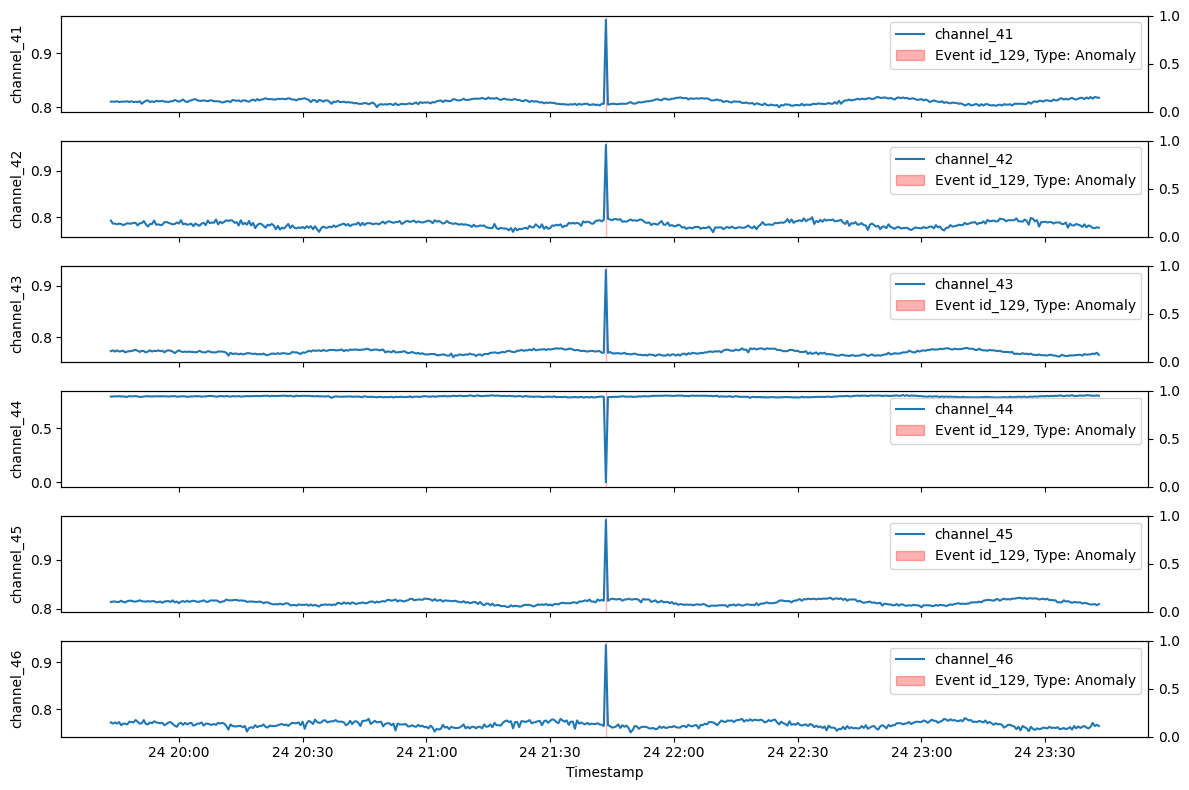

In [167]:
def plotting_pred(
    df,
    pred_df,
    anomaly_subset,
    subset_channels,
    labels_in_timeperiod,
    target_anomaly_id
):

    # find anomalies with id in time period
    target_anomaly_df = labels_in_timeperiod[
        labels_in_timeperiod['ID'] == target_anomaly_id
    ]

    anomaly_start_time = target_anomaly_df['StartTime'].min() - pd.Timedelta(hours=1)
    anomaly_end_time   = target_anomaly_df['EndTime'].max() + pd.Timedelta(hours=1)

    anomaly_length = anomaly_end_time - anomaly_start_time

    print(
        f"Anomaly ID: {target_anomaly_id}, "
        f"Start: {anomaly_start_time}, "
        f"End: {anomaly_end_time}, "
        f"Length: {anomaly_length}"
    )

    anomaly_plot_start = anomaly_start_time - anomaly_length / 2
    anomaly_plot_end   = anomaly_end_time   + anomaly_length / 2

    # filter signal data
    anomaly_df = df[
        (df['timestamp'] >= anomaly_plot_start) &
        (df['timestamp'] <  anomaly_plot_end)
    ].copy()

    # filter prediction data
    pred_anomaly_df = pred_df[
        (pred_df['timestamp'] >= anomaly_plot_start) &
        (pred_df['timestamp'] <  anomaly_plot_end)
    ].copy()

    # create figure
    fig, axs = plt.subplots(
        len(subset_channels),
        1,
        figsize=(12, 8),
        sharex=True
    )

    anomaly_type = anomaly_types_df.loc[
        anomaly_types_df['ID'] == target_anomaly_id, 'Category'
    ].values[0]

    for i, channel in enumerate(subset_channels):

        # ---- raw signal ----
        axs[i].plot(
            anomaly_df['timestamp'],
            anomaly_df[channel],
            label=channel
        )
        axs[i].set_ylabel(channel)

        # ---- prediction (second y-axis) ----

        # only plot if 1 dont plot if zeros
        #pred_anomaly_df = pred_anomaly_df.replace(0, np.nan)

        # find timestamps where prediction == 1
        one_times = pred_anomaly_df.loc[
            pred_anomaly_df[channel] == 1, "timestamp"
        ]

        ax_pred = axs[i].twinx()

        first_pred = True
        for t in one_times:
            ax_pred.axvline(
                x=t,
                color="orange",
                linestyle="--",
                alpha=0.7,
                linewidth=1,
                label="Prediction" if first_pred else None
            )
            first_pred = False



        # ---- anomaly shading from labels ----
        mask = anomaly_df[f'is_anomaly_{channel}'] != 0
        groups = (mask != mask.shift()).cumsum()

        first = True
        for _, g in anomaly_df[mask].groupby(groups):
            axs[i].axvspan(
                g['timestamp'].iloc[0],
                g['timestamp'].iloc[-1],
                color='red',
                alpha=0.3,
                label=f'Event {target_anomaly_id}, Type: {anomaly_type}' if first else None
            )
            first = False

        # ---- legends (merge both axes) ----
        lines1, labels1 = axs[i].get_legend_handles_labels()
        lines2, labels2 = ax_pred.get_legend_handles_labels()
        axs[i].legend(lines1 + lines2, labels1 + labels2, loc='upper right')

    axs[-1].set_xlabel("Timestamp")
    plt.tight_layout()
    plt.show()


random_anomaly = np.random.choice(anomalies_ids_in_period['ID'])
print("Plotting anomaly ID:", random_anomaly)

plotting_pred(
    df,
    df_pred_profile,
    anomaly_subset,
    subset_channels,
    labels_in_timeperiod,
    target_anomaly_id=random_anomaly
)

In [168]:
results_path = r"transformer\results.csv"

results_df = pd.read_csv(results_path)

channel_thresholds = {
    ch: results_df.loc[0, f"threshold_{ch}"]
    for ch in subset_channels
}
print("Channel thresholds:", channel_thresholds)

Channel thresholds: {'channel_41': np.float64(0.0013885768665932), 'channel_42': np.float64(0.0013885768665932), 'channel_43': np.float64(0.0013885768665932), 'channel_44': np.float64(0.0013885768665932), 'channel_45': np.float64(0.0013885768665932), 'channel_46': np.float64(0.0013885768665932)}


Plotting anomaly ID: id_26


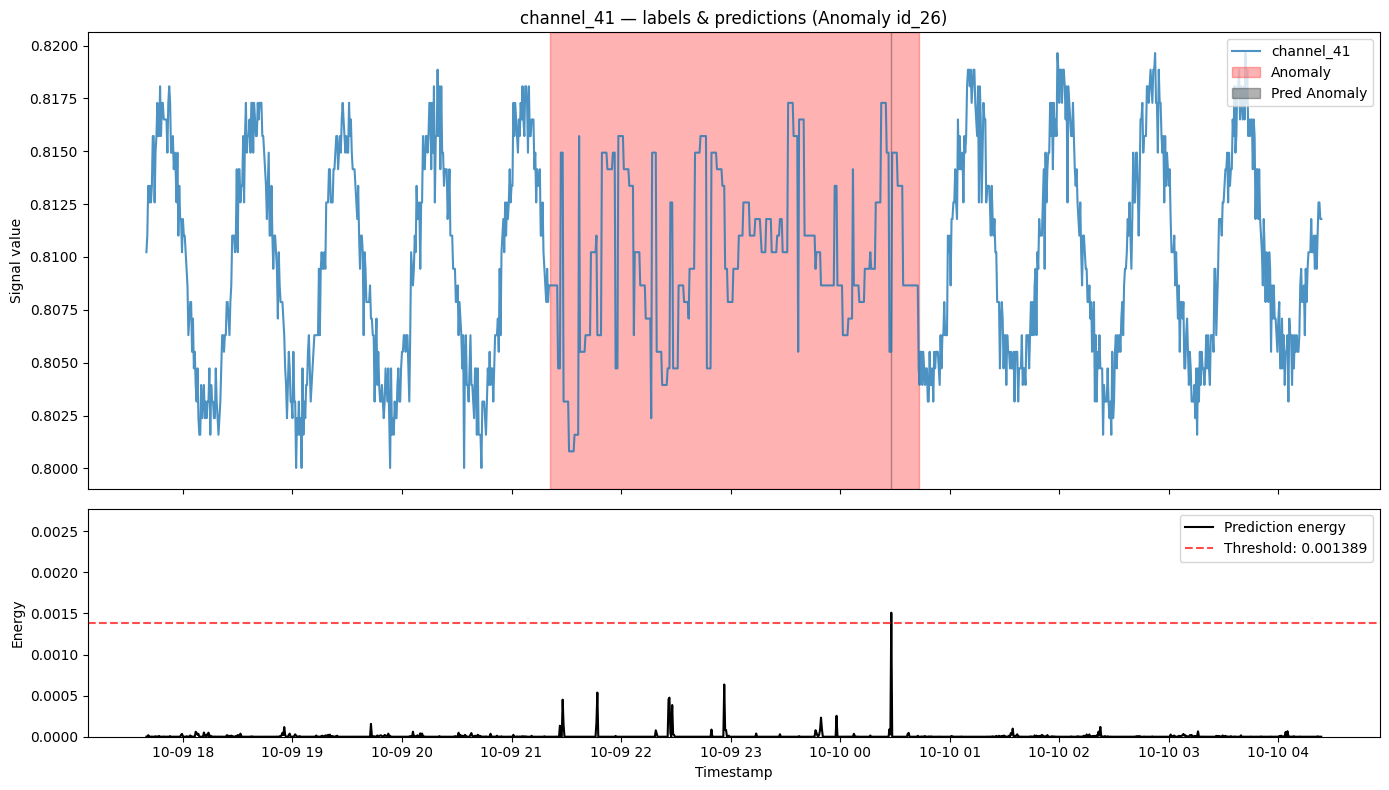

In [ ]:

def plotting_energy_single_channel(
    df,
    pred_df,
    energy_df,
    labels_in_timeperiod,
    target_anomaly_id,
    target_channel,
    channel_thresholds
):
    # --------------------------------------------------
    # Find anomaly time window
    # --------------------------------------------------
    target_anomaly_df = labels_in_timeperiod[
        labels_in_timeperiod["ID"] == target_anomaly_id
    ]

    anomaly_start_time = target_anomaly_df["StartTime"].min() - pd.Timedelta(hours=1)
    anomaly_end_time   = target_anomaly_df["EndTime"].max() + pd.Timedelta(hours=1)

    anomaly_length = anomaly_end_time - anomaly_start_time

    anomaly_plot_start = anomaly_start_time - anomaly_length / 2
    anomaly_plot_end   = anomaly_end_time   + anomaly_length / 2

    # --------------------------------------------------
    # Filter data
    # --------------------------------------------------
    anomaly_df = df[
        (df["timestamp"] >= anomaly_plot_start) &
        (df["timestamp"] <  anomaly_plot_end)
    ].copy()

    pred_anomaly_df = pred_df[
        (pred_df["timestamp"] >= anomaly_plot_start) &
        (pred_df["timestamp"] <  anomaly_plot_end)
    ].copy()

    energy_anomaly_df = energy_df[
        (energy_df["timestamp"] >= anomaly_plot_start) &
        (energy_df["timestamp"] <  anomaly_plot_end)
    ].copy()

    # --------------------------------------------------
    # Create figure (2 rows)
    # --------------------------------------------------
    fig, axs = plt.subplots(
        2, 1, figsize=(14, 8), sharex=True,
        gridspec_kw={"height_ratios": [2, 1]}
    )

    # ==================================================
    # TOP: signal + anomalous labels + predictions
    # ==================================================
    ax_sig = axs[0]

    # raw signal
    ax_sig.plot(
        anomaly_df["timestamp"],
        anomaly_df[target_channel],
        label=target_channel,
        alpha=0.8
    )

    # labelled anomalies
    label_mask = anomaly_df[f"is_anomaly_{target_channel}"] != 0

    
    # ---- anomaly shading from labels ----
    mask = anomaly_df[f'is_anomaly_{channel}'] != 0
    groups = (mask != mask.shift()).cumsum()

    first = True
    for _, g in anomaly_df[mask].groupby(groups):
        axs[0].axvspan(
            g['timestamp'].iloc[0],
            g['timestamp'].iloc[-1],
            color='red',
            alpha=0.3,
            label=f'Anomaly' if first else None
        )
        first = False

    # ---- anomaly shading from labels ----
    pred_mask = pred_anomaly_df[target_channel] == 1
    groups = (pred_mask != pred_mask.shift()).cumsum()

    first = True
    for _, g in pred_anomaly_df[pred_mask].groupby(groups):
        axs[0].axvspan(
            g['timestamp'].iloc[0],
            g['timestamp'].iloc[-1],
            color='black',
            alpha=0.3,
            label=f'Pred Anomaly' if first else None
        )
        first = False


    ax_sig.set_ylabel("Signal value")
    ax_sig.set_title(
        f"Transformer Detections and Detection Energy (Anomaly {target_anomaly_id} in {target_channel})"
    )
    ax_sig.legend(loc="upper right")

    # ==================================================
    # BOTTOM: energy + threshold
    # ==================================================
    ax_energy = axs[1]

    ax_energy.plot(
        energy_anomaly_df["timestamp"],
        energy_anomaly_df[target_channel],
        label="Prediction energy",
        color="black"
    )

    thr = channel_thresholds.get(target_channel)
    if thr is not None and not pd.isna(thr):
        ax_energy.axhline(
            thr,
            linestyle="--",
            color="red",
            alpha=0.7,
            label=f"Threshold: {thr:.6f}"
        )

    ax_energy.set_ylabel("Energy")
    ax_energy.set_xlabel("Timestamp")
    ax_energy.legend(loc="upper right")
    ax_energy.set_ylim(0, thr * 2)

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------
# Example call
# ------------------------------------------------------
random_anomaly = np.random.choice(anomalies_ids_in_period["ID"])
print("Plotting anomaly ID:", random_anomaly)

plotting_energy_single_channel(
    df=df,
    pred_df=df_pred_transformer,
    energy_df=df_pred_energy_transformer,
    labels_in_timeperiod=labels_in_timeperiod,
    target_anomaly_id=random_anomaly,
    target_channel="channel_41",
    channel_thresholds=channel_thresholds
)




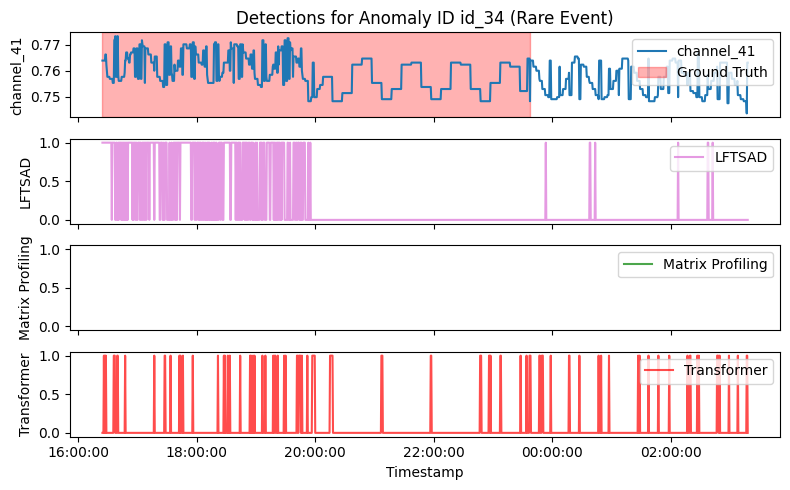

In [258]:
def plotting_pred_single_channel_three_dfs(
    df,
    pred_df_1,
    pred_df_2,
    pred_df_3,
    channel,
    labels_in_timeperiod,
    target_anomaly_id,
    pred1_name="Prediction 1",
    pred2_name="Prediction 2",
    pred3_name="Prediction 3",
):

    # ---- find anomaly window ----
    target_anomaly_df = labels_in_timeperiod[
        labels_in_timeperiod['ID'] == target_anomaly_id
    ]

    anomaly_start_time = target_anomaly_df['StartTime'].min() - pd.Timedelta(hours=1)
    anomaly_end_time   = target_anomaly_df['EndTime'].max()   + pd.Timedelta(hours=1)

    anomaly_length = anomaly_end_time - anomaly_start_time
    anomaly_plot_start = anomaly_start_time - anomaly_length / 2
    anomaly_plot_end   = anomaly_end_time   + anomaly_length / 2

    # ---- filter signal ----
    anomaly_df = df[
        (df['timestamp'] >= anomaly_plot_start) &
        (df['timestamp'] <  anomaly_plot_end)
    ]

    # ---- filter predictions ----
    pred_df_1 = pred_df_1[
        (pred_df_1['timestamp'] >= anomaly_plot_start) &
        (pred_df_1['timestamp'] <  anomaly_plot_end)
    ]

    pred_df_2 = pred_df_2[
        (pred_df_2['timestamp'] >= anomaly_plot_start) &
        (pred_df_2['timestamp'] <  anomaly_plot_end)
    ]

    pred_df_3 = pred_df_3[
        (pred_df_3['timestamp'] >= anomaly_plot_start) &
        (pred_df_3['timestamp'] <  anomaly_plot_end)
    ]

    anomaly_type = anomaly_types_df.loc[
        anomaly_types_df['ID'] == target_anomaly_id, 'Category'
    ].values[0]

    # ---- subplots ----
    fig, axs = plt.subplots(4, 1, figsize=(8, 5), sharex=True)

    # =========================
    # 1) RAW SIGNAL
    # =========================
    axs[0].plot(anomaly_df['timestamp'], anomaly_df[channel], label=channel)
    axs[0].set_ylabel(channel)
    axs[0].set_title(f"Detections for Anomaly ID {target_anomaly_id} ({anomaly_type})")

    mask = anomaly_df[f'is_anomaly_{channel}'] != 0
    groups = (mask != mask.shift()).cumsum()

    first = True
    for _, g in anomaly_df[mask].groupby(groups):
        axs[0].axvspan(
            g['timestamp'].iloc[0],
            g['timestamp'].iloc[-1],
            color='red',
            alpha=0.3,
            label="Ground Truth" if first else None
        )
        first = False

    axs[0].legend(loc="upper right")

    # =========================
    # 2) PREDICTION DF 1
    # =========================
    axs[1].plot(pred_df_1['timestamp'], pred_df_1[channel], label=pred1_name, alpha = 0.7, c = 'orchid')
    axs[1].set_ylabel(pred1_name)
    axs[1].set_ylim(-0.05, 1.05)
    axs[1].legend(loc="upper right")

    # =========================
    # 3) PREDICTION DF 2
    # =========================
    axs[2].plot(pred_df_2['timestamp'], pred_df_2[channel], label=pred2_name, alpha = 0.7, c = 'green')
    axs[2].set_ylabel(pred2_name)
    axs[2].set_ylim(-0.05, 1.05)
    axs[2].legend(loc="upper right")

    # =========================
    # 4) PREDICTION DF 3
    # =========================
    axs[3].plot(pred_df_3['timestamp'], pred_df_3[channel], label=pred3_name, alpha = 0.7, c = 'red')
    axs[3].set_ylabel(pred3_name)
    axs[3].set_ylim(-0.05, 1.05)
    axs[3].legend(loc="upper right")
    axs[3].set_xlabel("Timestamp")

   
    import matplotlib.dates as mdates
    # 1. Set the limits to eliminate side margins
    #axs[-1].set_xlim(anomaly_start_time, anomaly_end_time)
    axs[-1].xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=6))

    # 2. Format the Ticks
    # Calculate the total duration of the window
    window_duration = anomaly_plot_end - anomaly_plot_start


    # --- AUTO-SELECTION LOGIC ---
    if window_duration > pd.Timedelta(days=1):
        # SHORT: Focus on dates for long windows
        date_fmt = '%Y-%m-%d'
        # Show a tick every day (or every few days)
        locator = mdates.AutoDateLocator(maxticks=6)
    else:
        # PRECISE: Focus on time for short bursts
        date_fmt = '%H:%M:%S'
        # Show a tick every hour or minute as needed
        locator = mdates.AutoDateLocator(maxticks=8)

    # Apply to the bottom axis
   
    axs[-1].xaxis.set_major_formatter(mdates.DateFormatter(date_fmt))
    axs[-1].xaxis.set_major_locator(locator)

    
    # Apply to the bottom axis
    # 4. Stylize the labels
    #plt.setp(axs[-1].get_xticklabels(), rotation=0, ha='center', fontsize=10)

    # 5. Remove the "offset" text (that tiny '+1.23e9' in the corner)
    axs[-1].xaxis.get_offset_text().set_visible(False)

    plt.tight_layout()
    plt.show()

random_anomaly = np.random.choice(anomalies_ids_in_period['ID'])

plotting_pred_single_channel_three_dfs(
    df,
    df_pred_lftsad,
    df_pred_profile,
    df_pred_transformer,
    channel = 'channel_41',
    labels_in_timeperiod = labels_in_timeperiod,
    target_anomaly_id = random_anomaly,
    pred1_name="LFTSAD",
    pred2_name="Matrix Profiling",
    pred3_name="Transformer",
)

c:\Users\angus\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


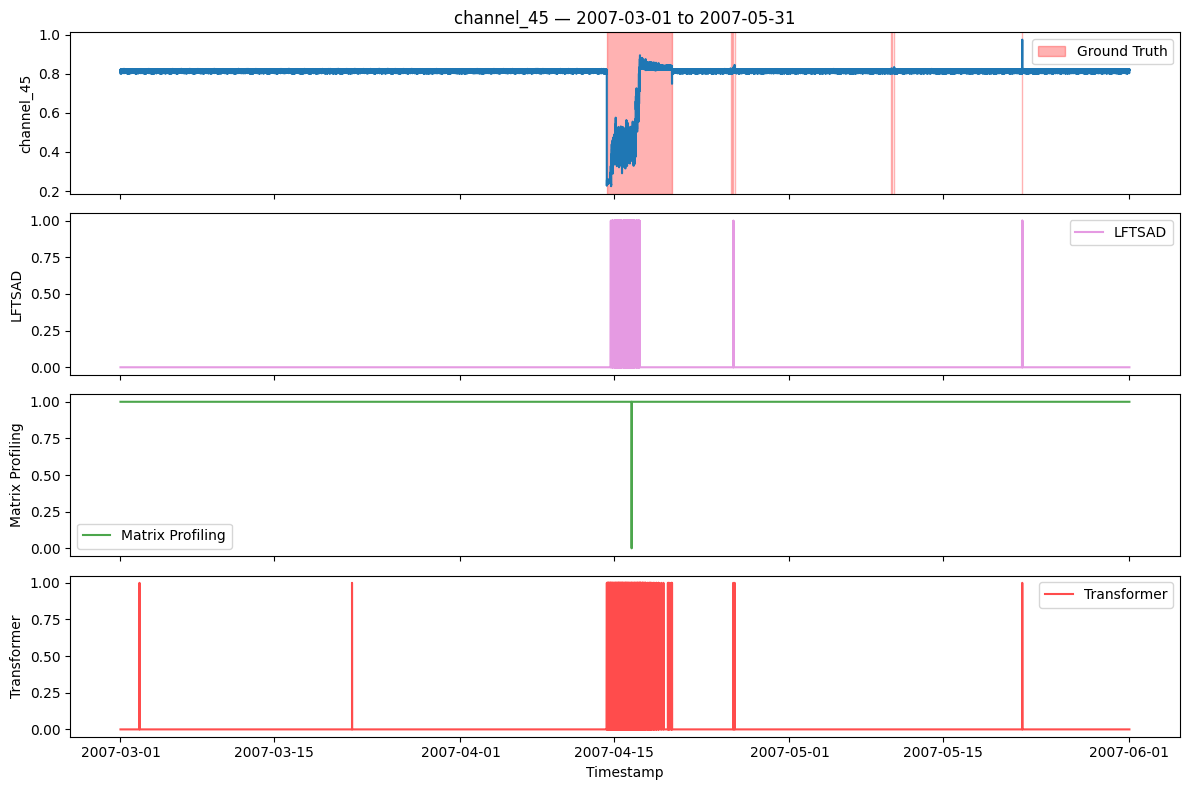

In [179]:
def plotting_pred_single_channel_three_dfs_span(
    df,
    pred_df_1,
    pred_df_2,
    pred_df_3,
    channel,
    year,
    start_month,
    months_length=3,
    pred1_name="Prediction 1",
    pred2_name="Prediction 2",
    pred3_name="Prediction 3",
    show_gt_anomalies=True,
):

    start_time = pd.Timestamp(year=year, month=start_month, day=1)
    end_time   = start_time + pd.DateOffset(months=months_length)

    # ---- masks ----
    mask_df = (df['timestamp'] >= start_time) & (df['timestamp'] < end_time)
    mask_p1 = (pred_df_1['timestamp'] >= start_time) & (pred_df_1['timestamp'] < end_time)
    mask_p2 = (pred_df_2['timestamp'] >= start_time) & (pred_df_2['timestamp'] < end_time)
    mask_p3 = (pred_df_3['timestamp'] >= start_time) & (pred_df_3['timestamp'] < end_time)

    fig, axs = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

    # RAW
    axs[0].plot(df.loc[mask_df, 'timestamp'],
                df.loc[mask_df, channel])
    axs[0].set_ylabel(channel)
    axs[0].set_title(
        f"{channel} — {start_time.date()} to {(end_time - pd.Timedelta(days=1)).date()}"
    )

    if show_gt_anomalies and f'is_anomaly_{channel}' in df.columns:
        year_df = df.loc[mask_df]
        mask = year_df[f'is_anomaly_{channel}'] != 0
        groups = (mask != mask.shift()).cumsum()

        first = True
        for _, g in year_df[mask].groupby(groups):
            axs[0].axvspan(
                g['timestamp'].iloc[0],
                g['timestamp'].iloc[-1],
                color='red',
                alpha=0.3,
                label="Ground Truth" if first else None
            )
            first = False
        axs[0].legend()


    # PRED1
    axs[1].plot(pred_df_1.loc[mask_p1, 'timestamp'],
                pred_df_1.loc[mask_p1, channel],
                label=pred1_name, alpha = 0.7, c = 'orchid')
    axs[1].set_ylabel(pred1_name)
    axs[1].set_ylim(-0.05, 1.05)
    axs[1].legend()

    # PRED2
    axs[2].plot(pred_df_2.loc[mask_p2, 'timestamp'],
                pred_df_2.loc[mask_p2, channel],
                label=pred2_name, alpha = 0.7, c = 'green')
    axs[2].set_ylabel(pred2_name)
    axs[2].set_ylim(-0.05, 1.05)
    axs[2].legend()

    # PRED3
    axs[3].plot(pred_df_3.loc[mask_p3, 'timestamp'],
                pred_df_3.loc[mask_p3, channel],
                label=pred3_name, alpha = 0.7, c = 'red')
    axs[3].set_ylabel(pred3_name)
    axs[3].set_ylim(-0.05, 1.05)
    axs[3].legend()
    axs[3].set_xlabel("Timestamp")

    plt.tight_layout()
    plt.show()


plotting_pred_single_channel_three_dfs_span(
    df=df,
    pred_df_1=df_pred_lftsad,
    pred_df_2=df_pred_profile,
    pred_df_3= df_pred_transformer,
    channel="channel_45",
    year=2007,
    start_month = 3,
    months_length= 3,
    pred1_name="LFTSAD",
    pred2_name="Matrix Profiling",
    pred3_name = "Transformer",
    show_gt_anomalies=True,  # set False if you want zero anomaly logic
)


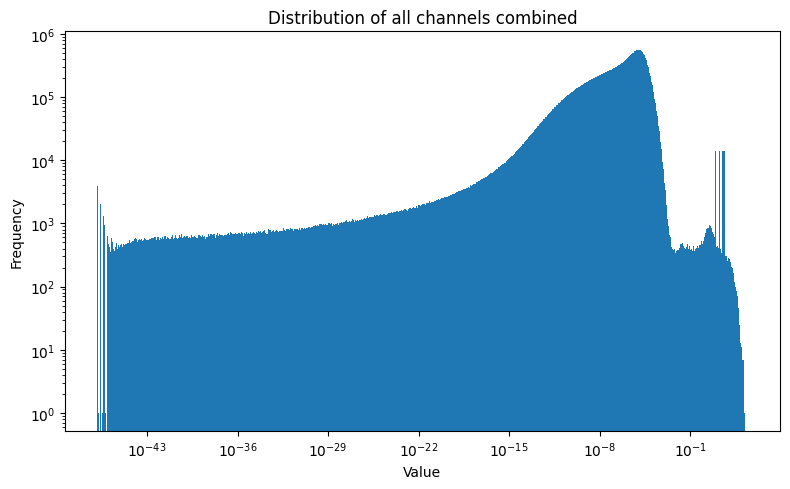

In [262]:
def plot_combined_hist(
    df,
    channel_cols,
    bins=200,
    log_x=True,
    log_y=True,
    drop_zeros=True,
    title="Distribution of all channels combined"
):
    """
    Plot a single histogram from multiple channels with optional log-x bins.
    """

    # --- determine global min / max (required for shared log bins)
    global_min = np.inf
    global_max = -np.inf

    for col in channel_cols:
        data = df[col].to_numpy(copy=False)

        if drop_zeros:
            data = data[data > 0]

        if len(data) == 0:
            continue

        global_min = min(global_min, data.min())
        global_max = max(global_max, data.max())

    if log_x:
        if global_min <= 0:
            raise ValueError("Log-x histogram requires all values > 0")

        bin_edges = np.logspace(
            np.log10(global_min),
            np.log10(global_max),
            bins + 1
        )
    else:
        bin_edges = np.linspace(global_min, global_max, bins + 1)

    # --- accumulate histogram
    hist = np.zeros(len(bin_edges) - 1)

    for col in channel_cols:
        data = df[col].to_numpy(copy=False)

        if drop_zeros:
            data = data[data > 0]

        h, _ = np.histogram(data, bins=bin_edges)
        hist += h

    # --- plot
    plt.figure(figsize=(8, 5))
    plt.bar(
        bin_edges[:-1],
        hist,
        width=np.diff(bin_edges),
        align="edge"
    )

    if log_x:
        plt.xscale("log")
    if log_y:
        plt.yscale("log")

    plt.xlabel("Value")
    #plt.xlim(1e-5)
    plt.ylabel("Frequency")
    plt.title(title)
    plt.tight_layout()
    plt.show()



vali_energy = r"transformer\vali_energy.csv"

df_val_energy = pd.read_csv(vali_energy)

channel_cols = df_val_energy.columns

plot_combined_hist(
    df_pred_energy_transformer,
    channel_cols,
    bins=1000,
    log_x = True,
    log_y=True,
    drop_zeros=True
)



In [173]:
def anomaly_interval_analysis(
    df,
    channel_cols,
    intervals,
    drop_zeros=True
):
    """
    Count anomaly scores in predefined intervals.

    intervals: list of tuples
        e.g. [(0, np.inf), (0, 1e-2), (1e-2, 0.1), (0.1, np.inf)]
    """

    counts = {interval: 0 for interval in intervals}

    for col in channel_cols:
        data = df[col].to_numpy(copy=False)

        if drop_zeros:
            data = data[data > 0]

        for low, high in intervals:
            if low == 0:
                mask = (data >= low) & (data <= high)
            else:
                mask = (data > low) & (data <= high)

            counts[(low, high)] += mask.sum()

    return counts

intervals_smap = [
    (0, np.inf),
    (0, 1e-3),
    (1e-4, 5e-3),
    (5e-3, np.inf),
]


counts = anomaly_interval_analysis(
    df_val_energy,
    channel_cols,
    intervals_smap
)

total = counts[(0, np.inf)]
ratio_tail = counts[(5e-3, np.inf)] / total * 100

print("Anomaly Score Interval Analysis\n")

for (low, high), c in counts.items():
    print(f"({low:g}, {high:g}] : {c}")

print(f"\nRatio of (0.1, +∞] : {ratio_tail:.2f}%")



Anomaly Score Interval Analysis

(0, inf] : 1556740
(0, 0.001] : 1555296
(0.0001, 0.005] : 106422
(0.005, inf] : 32

Ratio of (0.1, +∞] : 0.00%
